# 07 — Visualisation

This notebook produces the final publication-quality figures and interactive maps for the project. These are the outputs that go in the GitHub README, the video, and the project report.

**Outputs:**
- Animated GIF cycling through all four classification epochs
- Interactive Folium map with toggleable layers
- Side-by-side true colour vs classification comparison
- Summary figure combining key results

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rasterio folium imageio --quiet

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import imageio
import folium
from folium import plugins
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [3]:
# File paths
outputs_path  = '/content/drive/MyDrive/GEOL0069/Project/Data/Outputs'
processed_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Processed'

epochs = ['2019', '2021', '2023', '2025']

class_names = {
    1: 'Dense woodland',
    2: 'Cropland',
    3: 'Grassland / pasture',
    4: 'Water',
    5: 'Wetland / floodplain',
    6: 'Built-up / urban',
}

class_colours = {
    1: '#1a6b3a',
    2: '#a8c66c',
    3: '#d4e8a0',
    4: '#3b82c4',
    5: '#7ecece',
    6: '#d97706',
}

cmap_colours = ['#ffffff'] + [class_colours[i] for i in range(1, 7)]
lc_cmap = mcolors.ListedColormap(cmap_colours)
lc_norm = mcolors.BoundaryNorm(range(8), lc_cmap.N)

print("Paths and class definitions set")

Paths and class definitions set


In [4]:
# Load all classification maps
print("Loading classification maps...")
unet_maps = {}

for epoch in epochs:
    path = os.path.join(outputs_path, f'unet_{epoch}.tif')
    with rasterio.open(path) as src:
        unet_maps[epoch] = src.read(1)

print("Maps loaded")

Loading classification maps...
Maps loaded


## Figure 1 — Animated GIF

An animated GIF cycling through the four classification maps. This goes at the top of the GitHub README as the first thing an examiner sees when they open the repository.

In [5]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import imageio

# --- FIX: Re-load unet_maps as it was not populated correctly in the previous cell ---
print("Re-loading classification maps for GIF generation...")
unet_maps = {}

for epoch in epochs:
    path = os.path.join(outputs_path, f'unet_{epoch}.tif')
    with rasterio.open(path) as src:
        unet_maps[epoch] = src.read(1)
print("Classification maps re-loaded.")
# -----------------------------------------------------------------------------------

def map_to_rgb(class_map, cmap, norm):
    """Converts a classified integer map to an RGB image array for saving."""
    rgba = cmap(norm(class_map))
    return (rgba[:, :, :3] * 255).astype(np.uint8)


# Generate one frame per epoch
print("Generating GIF frames...")
frames = []

for epoch in epochs:
    fig, ax = plt.subplots(figsize=(7, 7.5))
    ax.imshow(unet_maps[epoch], cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(f'Cambridge A14 Corridor — {epoch}', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

    legend_patches = [
        mpatches.Patch(color=class_colours[i], label=class_names[i])
        for i in range(1, 7)
    ]
    ax.legend(handles=legend_patches, loc='lower right',
              fontsize=8, framealpha=0.95, title='Land cover')

    # Save frame to buffer
    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    frame = np.asarray(buf)[:, :, :3]
    frames.append(frame)
    plt.close(fig)
    print(f"  Frame {epoch} done")
    plt.show()

# Save as GIF
gif_path = os.path.join(outputs_path, 'classification_animated.gif')
imageio.mimsave(gif_path, frames, fps=1, loop=0)

print(f"\nGIF saved: {gif_path}")
print("Copy this file into your GitHub repository root folder for the README")

Re-loading classification maps for GIF generation...
Classification maps re-loaded.
Generating GIF frames...
  Frame 2019 done
  Frame 2021 done
  Frame 2023 done
  Frame 2025 done

GIF saved: /content/drive/MyDrive/GEOL0069/Project/Data/Outputs/classification_animated.gif
Copy this file into your GitHub repository root folder for the README


Side by side comparison of the 2019 and 2025 true colour Sentinel-2 imagery alongside the classification maps. This is the visual that opens your video.


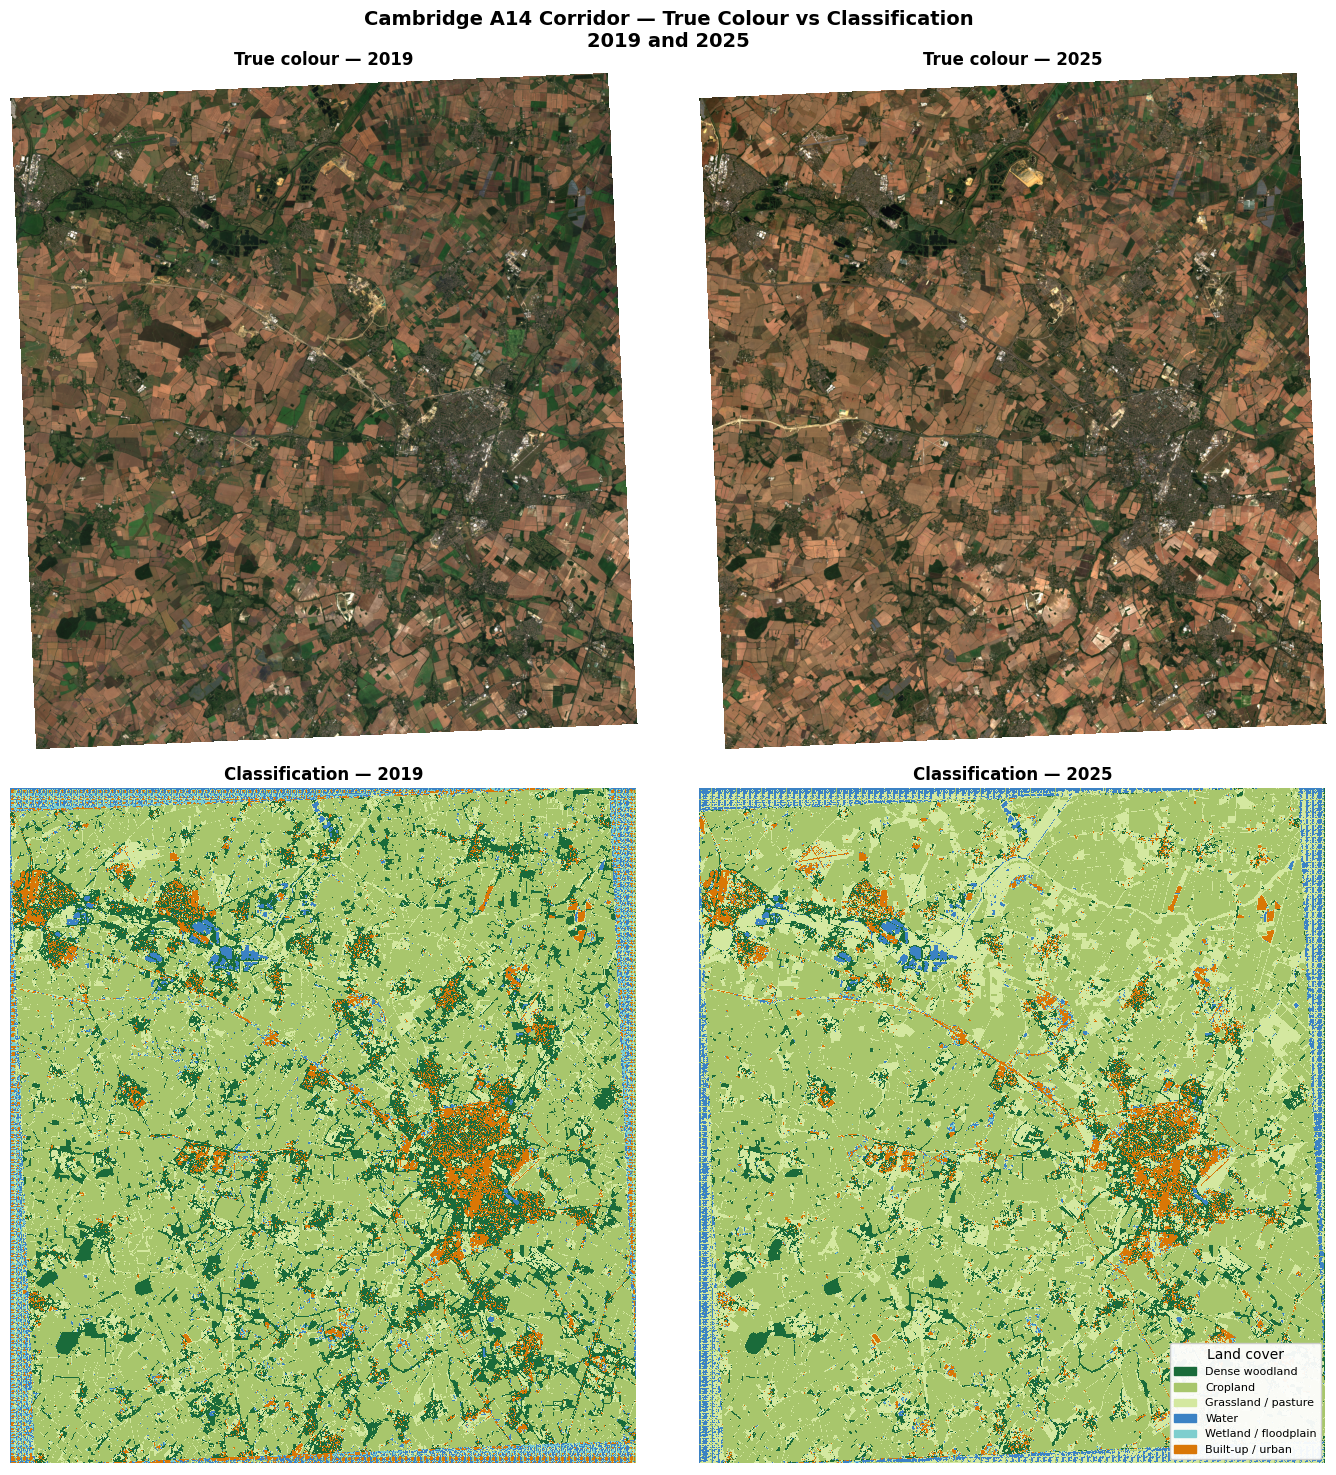

Figure saved


In [6]:
def load_true_colour(epoch, brightness=3.5):
    """Loads Sentinel-2 true colour composite."""
    path = os.path.join(processed_path, f'S2_{epoch}_10m.tif')
    with rasterio.open(path) as src:
        red   = src.read(3).astype(float)
        green = src.read(2).astype(float)
        blue  = src.read(1).astype(float)
    rgb = np.dstack([red, green, blue])
    return np.clip(rgb * brightness, 0, 1)


fig, axes = plt.subplots(2, 2, figsize=(14, 15))

# Top row: true colour
for col, epoch in enumerate(['2019', '2025']):
    axes[0, col].imshow(load_true_colour(epoch))
    axes[0, col].set_title(f'True colour — {epoch}', fontsize=12, fontweight='bold')
    axes[0, col].axis('off')

# Bottom row: classification
for col, epoch in enumerate(['2019', '2025']):
    axes[1, col].imshow(unet_maps[epoch], cmap=lc_cmap, norm=lc_norm,
                        interpolation='nearest')
    axes[1, col].set_title(f'Classification — {epoch}', fontsize=12, fontweight='bold')
    axes[1, col].axis('off')

legend_patches = [
    mpatches.Patch(color=class_colours[i], label=class_names[i])
    for i in range(1, 7)
]
axes[1, 1].legend(handles=legend_patches, loc='lower right',
                  fontsize=8, framealpha=0.95, title='Land cover')

plt.suptitle('Cambridge A14 Corridor — True Colour vs Classification\n2019 and 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'true_colour_vs_classification.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

A single figure combining the four key results: the four-epoch classification maps, the change detection map, the area statistics chart, and the model accuracy comparison. This is the centrepiece figure for the README and report.


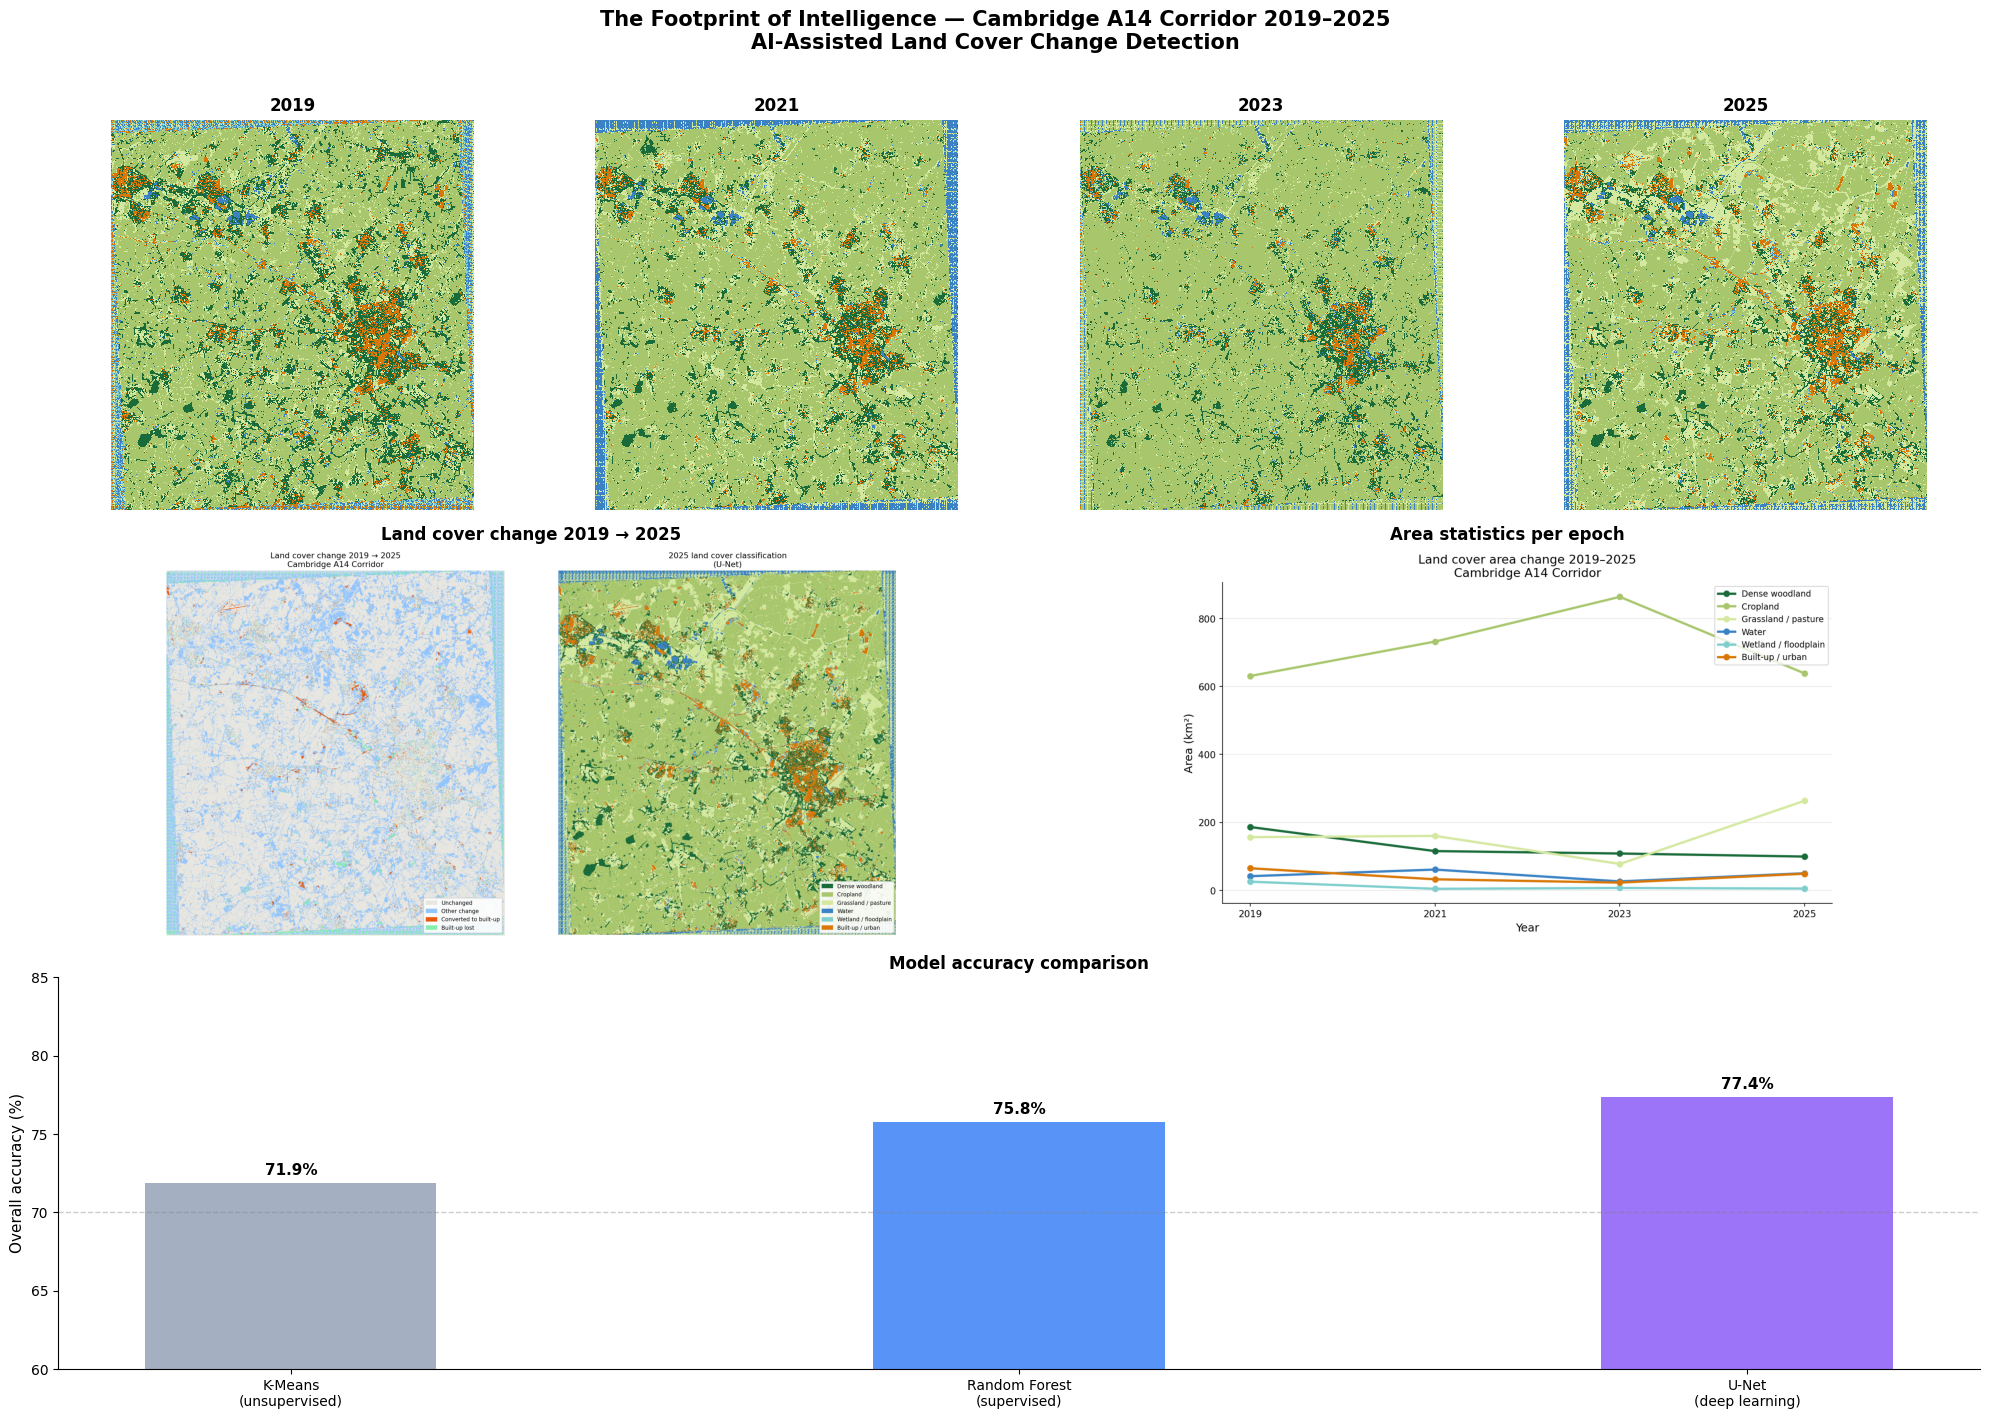

Summary panel saved


In [7]:
# Load change map
change_map_path = os.path.join(outputs_path, 'change_map_2019_2025.png')
change_img = plt.imread(change_map_path)

# Load area statistics
area_stats_path = os.path.join(outputs_path, 'area_statistics.png')
area_img = plt.imread(area_stats_path)

# Build summary panel
fig = plt.figure(figsize=(20, 14))

# Top row: four classification maps
for i, epoch in enumerate(epochs):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.imshow(unet_maps[epoch], cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(epoch, fontsize=12, fontweight='bold')
    ax.axis('off')

# Middle left: change map
ax_change = fig.add_subplot(3, 2, 3)
ax_change.imshow(change_img)
ax_change.axis('off')
ax_change.set_title('Land cover change 2019 → 2025', fontsize=12, fontweight='bold')

# Middle right: area statistics
ax_area = fig.add_subplot(3, 2, 4)
ax_area.imshow(area_img)
ax_area.axis('off')
ax_area.set_title('Area statistics per epoch', fontsize=12, fontweight='bold')

# Bottom: accuracy comparison bar chart
ax_acc = fig.add_subplot(3, 1, 3)

models  = ['K-Means\n(unsupervised)', 'Random Forest\n(supervised)', 'U-Net\n(deep learning)']
oa      = [71.9, 75.8, 77.4]
colours = ['#94a3b8', '#3b82f6', '#8b5cf6']

bars = ax_acc.bar(models, oa, color=colours, alpha=0.85, width=0.4)
ax_acc.set_ylim(60, 85)
ax_acc.set_ylabel('Overall accuracy (%)', fontsize=11)
ax_acc.set_title('Model accuracy comparison', fontsize=12, fontweight='bold')
ax_acc.spines['top'].set_visible(False)
ax_acc.spines['right'].set_visible(False)
ax_acc.axhline(y=70, color='gray', linestyle='--', alpha=0.4, linewidth=1)

for bar, val in zip(bars, oa):
    ax_acc.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('The Footprint of Intelligence — Cambridge A14 Corridor 2019–2025\nAI-Assisted Land Cover Change Detection',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'summary_panel.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Summary panel saved")

An interactive HTML map built with Folium that lets the viewer toggle between the four classification epochs and the change detection layer. This goes in the outputs folder and can be opened in any browser.


In [8]:
from matplotlib.colors import to_hex
import base64
from io import BytesIO

def classification_map_to_image(class_map, cmap, norm, downsample=4):
    """
    Converts a classification map to a PNG image encoded as base64.
    Downsamples for web display to keep file size manageable.
    """
    # Downsample
    ds_map = class_map[::downsample, ::downsample]

    fig, ax = plt.subplots(figsize=(8, 8.5))
    ax.imshow(ds_map, cmap=cmap, norm=norm, interpolation='nearest')
    ax.axis('off')
    plt.tight_layout(pad=0)

    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=80, bbox_inches='tight', pad_inches=0)
    plt.close()
    buf.seek(0)

    return base64.b64encode(buf.read()).decode('utf-8')


# Cambridge centre coordinates
cambridge_lat = 52.20
cambridge_lon = 0.12

# Create base map
m = folium.Map(
    location=[cambridge_lat, cambridge_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Add OpenStreetMap as optional base layer
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)

# Study area bounding box
bounds = [[52.08, -0.20], [52.38, 0.25]]

# Add each epoch as an image overlay
colours_for_epoch = {
    '2019': 'rgba(59,130,246,0.7)',
    '2021': 'rgba(16,185,129,0.7)',
    '2023': 'rgba(245,158,11,0.7)',
    '2025': 'rgba(239,68,68,0.7)',
}

print("Generating map overlays (this takes a minute)...")

for epoch in epochs:
    img_b64 = classification_map_to_image(unet_maps[epoch], lc_cmap, lc_norm)

    folium.raster_layers.ImageOverlay(
        image=f"data:image/png;base64,{img_b64}",
        bounds=bounds,
        opacity=0.7,
        name=f'Classification {epoch}',
        show=(epoch == '2025')  # only show 2025 by default
    ).add_to(m)

    print(f"  {epoch} overlay added")

# Add layer control so user can toggle epochs
folium.LayerControl(collapsed=False).add_to(m)

# Add a legend as HTML
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 12px; font-family: sans-serif;">
<b>Land cover classes</b><br>
"""
for class_id, name in class_names.items():
    colour = class_colours[class_id]
    legend_html += f'<i style="background:{colour};width:12px;height:12px;display:inline-block;margin-right:6px;border-radius:2px"></i>{name}<br>'
legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

# Add title
title_html = """
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: white; padding: 10px 20px;
     border-radius: 8px; border: 1px solid #ccc;
     font-size: 14px; font-family: sans-serif; font-weight: bold;">
The Footprint of Intelligence — Cambridge A14 Corridor 2019–2025
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Save
map_path = os.path.join(outputs_path, 'interactive_map.html')
m.save(map_path)
print(f"\nInteractive map saved: {map_path}")
print("Open this file in a browser to view the interactive map")
plt.show()

Generating map overlays (this takes a minute)...
  2019 overlay added
  2021 overlay added
  2023 overlay added
  2025 overlay added

Interactive map saved: /content/drive/MyDrive/GEOL0069/Project/Data/Outputs/interactive_map.html
Open this file in a browser to view the interactive map


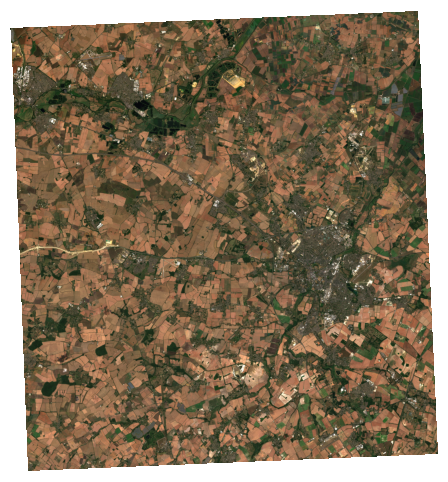

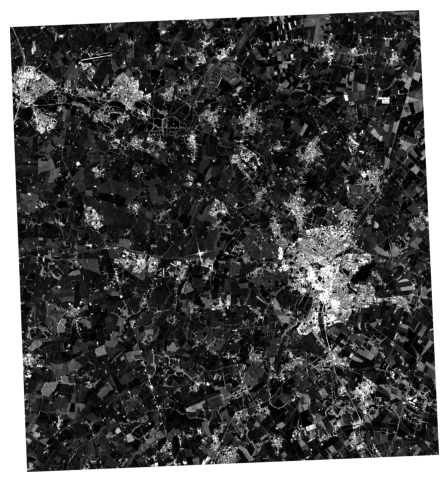

Both images saved to outputs folder


In [9]:
# Save Sentinel-2 true colour for pipeline diagram
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(load_true_colour('2025'))
ax.axis('off')
plt.savefig(os.path.join(outputs_path, 'sentinel2_true_colour.png'),
            dpi=150, bbox_inches='tight', pad_inches=0)
plt.show()

# Save Sentinel-1 VV backscatter for pipeline diagram
with rasterio.open(os.path.join(processed_path, 'S1_2025_processed.tif')) as src:
    vv = src.read(1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(vv, cmap='gray',
          vmin=np.percentile(vv, 2),
          vmax=np.percentile(vv, 98))
ax.axis('off')
plt.savefig(os.path.join(outputs_path, 'sentinel1_vv.png'),
            dpi=150, bbox_inches='tight', pad_inches=0)

ax.imshow(vv, cmap='gray',
          vmin=np.percentile(vv, 5),
          vmax=np.percentile(vv, 90))

plt.show()

print("Both images saved to outputs folder")

Confirming all output files are saved and ready for the GitHub repository.


In [10]:
print("=== FINAL OUTPUTS CHECKLIST ===\n")

expected_files = [
    'classification_animated.gif',
    'true_colour_vs_classification.png',
    'summary_panel.png',
    'interactive_map.html',
    'change_map_2019_2025.png',
    'area_statistics.png',
    'ndvi_trend.png',
    'environmental_impact.png',
    'unet_feature_sensitivity.png',
    'unet_confusion_matrix.png',
    'unet_four_epoch_panel.png',
    'unet_training_loss.png',
    'kmeans_all_epochs.png',
    'rf_all_epochs.png',
    'unet_all_epochs.png',
]

all_present = True
for filename in expected_files:
    path = os.path.join(outputs_path, filename)
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 if exists else 0
    status = f"  {filename:<45} {size:>8.1f} KB"

    if exists:
        print(status)
    else:
        print(f"  MISSING: {filename}")
        all_present = False

if all_present:
    print("\nAll output files present and accounted for.")
else:
    print("\nSome files are missing — check which notebooks need to be rerun.")

print("\nVisualisation complete.")
print("Next steps:")
print("  1. Download classification_animated.gif for your README header")
print("  2. Download interactive_map.html and open in a browser to check it")
print("  3. Move on to building your GitHub repository")

=== FINAL OUTPUTS CHECKLIST ===

  classification_animated.gif                      241.2 KB
  true_colour_vs_classification.png               4478.3 KB
  summary_panel.png                               1801.9 KB
  interactive_map.html                             767.3 KB
  change_map_2019_2025.png                         891.4 KB
  area_statistics.png                               91.5 KB
  ndvi_trend.png                                  2184.8 KB
  environmental_impact.png                         131.0 KB
  unet_feature_sensitivity.png                      83.5 KB
  unet_confusion_matrix.png                        122.7 KB
  MISSING: unet_four_epoch_panel.png
  unet_training_loss.png                            36.0 KB
  kmeans_all_epochs.png                            796.2 KB
  rf_all_epochs.png                               1193.9 KB
  unet_all_epochs.png                              832.4 KB

Some files are missing — check which notebooks need to be rerun.

Visualisation complete.